# Modified Puls Routing Extraction from HEC-RAS 2D Models

> **⚠️ BETA**: `RasModPuls` and this notebook are currently **beta** and have not yet been
> validated in production. The workflow, API, and outputs may change in future releases.
> We welcome feedback from third-party users looking to validate this methodology —
> please open an issue at https://github.com/gpt-cmdr/ras-commander/issues.

This notebook demonstrates the **Region 2 (Freese & Nichols) methodology** for extracting
Modified Puls storage-outflow (S-Q) tables from 2D HEC-RAS stepped-hydrograph simulations,
then writing the results into HEC-HMS paired data tables.

## What This Notebook Demonstrates

- Writing a stepped inflow hydrograph to a HEC-RAS unsteady flow file (`RasModPuls.write_stepped_hydrograph`)
- Executing the 2D HEC-RAS model over the stepped hydrograph
- Extracting the S-Q table from HDF results at plateau timesteps (`RasModPuls.extract_storage_outflow`)
- Computing subreach count for HEC-HMS (`RasModPuls.compute_subreach_count`)
- Writing S-Q results to HEC-HMS (`HmsBasin.set_modified_puls_routing`)
- Building reference lines from BC lines in the geometry HDF (`RasModPuls.add_reference_lines_from_bc_lines`)

## Modified Puls Method Background

Modified Puls (storage-indication) routing is a flood routing method used in HEC-HMS that
relates channel storage to outflow through an S-Q table. The Region 2 approach derives these
tables from 2D HEC-RAS models by:

1. Applying stepped inflow hydrographs (log-spaced from low to high)
2. Waiting for steady-state at each step (typically 24 hours per step)
3. Reading outflow Q from face flows at the downstream boundary
4. Reading storage S from cell depth × cell area summed across the mesh
5. Fitting an S-Q table for HMS routing

## Prerequisites

- HEC-RAS 6.5+ installed
- `ras-commander` installed (or local source)
- A 2D HEC-RAS project with face flow and cell depth outputs enabled
- (Optional) `hms-commander` for writing to HEC-HMS

In [1]:
# =============================================================================
# DEVELOPMENT MODE TOGGLE
# =============================================================================
USE_LOCAL_SOURCE = True  # <-- Set to False to use pip-installed package

if USE_LOCAL_SOURCE:
    import sys
    from pathlib import Path
    local_path = str(Path.cwd().parent)
    if local_path not in sys.path:
        sys.path.insert(0, local_path)
    print(f"LOCAL SOURCE MODE: Loading from {local_path}/ras_commander")
else:
    print("PIP PACKAGE MODE: Loading installed ras-commander")

import ras_commander
print(f"Loaded: {ras_commander.__file__}")

LOCAL SOURCE MODE: Loading from <workspace>/ras_commander


Loaded: <workspace>\ras_commander\__init__.py


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from ras_commander import (
    RasExamples, init_ras_project, RasCmdr, RasModPuls, ras
)
from ras_commander.hdf import HdfBndry, HdfMesh
from shapely.geometry import LineString

print("Imports complete")

Imports complete


---
## Example 1: Full Automated Workflow (Explicit Flow List)

This example uses the `BaldEagleCrkMulti2D` project — the standard HEC-RAS 2D Unsteady Flow
Hydraulics example with mesh face flow output. We write a stepped hydrograph with explicit
flow values, execute the model, and extract the S-Q table.

> **Engineering Note — Model Topology**: Plan 17 ("2D to 1D No Dam") is a **2D-to-1D
> connected model**: the `Upstream2D` mesh discharges into a downstream 1D river reach via
> an SA-to-River connection at XS 50335. In this topology, most flow exits through the
> SA-to-1D junction rather than through 2D mesh faces, so the face-flow Q extracted at the
> downstream transect will appear low relative to the total inflow. This is expected behavior
> for this example project — the library and method are working correctly. For production
> Modified Puls extraction, use a **self-contained 2D routing reach** with a downstream
> BC line (not a 1D connection) to ensure all outflow is captured as face flow.

### 1.1 — Setup: Extract and Initialize Project

In [3]:
# Configuration
PROJECT_NAME = "BaldEagleCrkMulti2D"   # 2D Unsteady Flow Hydraulics example
RAS_VERSION = "7.0"

# Plan selection — Plan 17 "2D to 1D No Dam" with 1MIN computation interval
# This plan has a single 2D mesh (Upstream2D) connected to a downstream 1D river reach
PLAN_NUMBER = "17"       # "2D to 1D No Dam"
UNSTEADY_NUMBER = "09"   # u09 — Upstream 2D unsteady flow file

# Stepped hydrograph parameters
# NOTE: Use 24h per step in production; 3h used here for a fast demo run (~780 timesteps)
FLOW_LIST = [500, 1000, 2000, 5000]   # cfs — explicit flow values (log-spaced in production)
STEP_DURATION_HOURS = 3.0   # Hours each step is held constant
WARMUP_FLOW = 100.0          # Optional low warmup flow before first step
WARMUP_DURATION = 1.0        # Hours for warmup step

# S-Q extraction parameters
N_ROWS = 15  # Number of rows in output S-Q table

# Extract example project
project_folder = RasExamples.extract_project(PROJECT_NAME, suffix="560ex1")
print(f"Project: {project_folder}")

# Initialize
init_ras_project(project_folder, RAS_VERSION)

print(f"\nAvailable plans:")
print(ras.plan_df[['plan_number', 'Plan Title', 'unsteady_number']].to_string(index=False))

plan_title = ras.plan_df[ras.plan_df['plan_number'] == PLAN_NUMBER]['Plan Title'].iloc[0]
print(f"\nUsing plan: {PLAN_NUMBER} ('{plan_title}')")
print(f"Unsteady file: u{UNSTEADY_NUMBER}")
print(f"\nStepped hydrograph: {len(FLOW_LIST)} steps × {STEP_DURATION_HOURS:.0f}h + {WARMUP_DURATION:.0f}h warmup")
total_h = WARMUP_DURATION + len(FLOW_LIST) * STEP_DURATION_HOURS
print(f"Total hydrograph duration: {total_h:.0f} hours (~{total_h*60:.0f} min at 1MIN CI)")


2026-06-11 16:59:29 - ras_commander.RasExamples - INFO - Successfully extracted project 'BaldEagleCrkMulti2D' to <workspace>\examples\example_projects\BaldEagleCrkMulti2D_560ex1


2026-06-11 16:59:29 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 7.0 at <hec_ras_install>\7.0\Ras.exe via filesystem (x86)


2026-06-11 16:59:29 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.7 Beta 5 at <hec_ras_install>\6.7 Beta 5\Ras.exe via filesystem (x86)


2026-06-11 16:59:29 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.6 at <hec_ras_install>\6.6\Ras.exe via filesystem (x86)


2026-06-11 16:59:29 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.5 at <hec_ras_install>\6.5\Ras.exe via filesystem (x86)


...

2026-06-11 16:59:29 - ras_commander.RasPrj - INFO - ras-commander v0.98.0 | An open-source project of CLB Engineering Corporation (https://clbengineering.com/) | Docs: https://rascommander.info | GitHub: https://github.com/gpt-cmdr/ras-commander


2026-06-11 16:59:29 - ras_commander.RasPrj - INFO - Project initialized: BaldEagleDamBrk | Folder: <workspace>\examples\example_projects\BaldEagleCrkMulti2D_560ex1


2026-06-11 16:59:29 - ras_commander.RasPrj - INFO - Using HEC-RAS executable: <hec_ras_install>\7.0\Ras.exe


2026-06-11 16:59:29 - ras_commander.RasPrj - INFO - 
═══════════════════════════════════════════════════════════════════════
ras-commander | HEC-RAS Automation Library
Docs: https://rascommander.info/
Repo: https://github.com/gpt-cmdr/ras-commander
═══════════════════════════════════════════════════════════════════════

PROJECT DATAFRAMES (single source of truth — use these, not file globbing):
  ras.plan_df        Plans, HDF paths, geometry/flow associations
  ras.geom_df        Geometry files and HDF preprocessor paths
  ras.flow_df        Steady flow files
  ras.unsteady_df    Unsteady flow files and configurations
  ras.boundaries_df  Boundary conditions (type, name, location)
  ras.results_df     Lightweight HDF results summaries
  ras.rasmap_df      RASMapper layers, terrain, land cover paths

KEY APIS (static classes — call directly, never instantiate):
  Execution:    RasCmdr.compute_plan() / compute_parallel() / compute_test_mode()
  Plan Files:   RasPlan.clone_plan() / clone_


Available plans:
plan_number                              Plan Title unsteady_number
         13                 PMF with Multi 2D Areas              07
         15             1d-2D Dambreak Refined Grid              12
         17                         2D to 1D No Dam              09
         18                            2D to 2D Run              10
         19                  SA to 2D Dam Break Run              11
         03 Single 2D Area - Internal Dam Structure              13
         04 SA to 2D Area Conn - 2D Levee Structure              01
         02                SA to Detailed 2D Breach              01
         01            SA to Detailed 2D Breach FEQ              01
         05         Single 2D area with Bridges FEQ              02
         06           Gridded Precip - Infiltration              03

Using plan: 17 ('2D to 1D No Dam')
Unsteady file: u09

Stepped hydrograph: 4 steps × 3h + 1h warmup
Total hydrograph duration: 13 hours (~780 min at 1MIN CI)


In [4]:
import re
from datetime import datetime, timedelta

# ── Enable HDF Face Flow output required by extract_storage_outflow ──────────
# Plan 17 does not include Face Flow in its HDF output by default.
# We insert HDF Face Flow=1 into the plan file before executing.
# NOTE: Cell Depth output is NOT required — storage is computed from
#       Water Surface minus Cells Minimum Elevation (always present in HDF).
plan_file = ras.project_folder / f"{ras.project_name}.p{PLAN_NUMBER}"
content = plan_file.read_text(encoding='utf-8', errors='replace')

if 'HDF Face Flow=' not in content:
    content = content.replace(
        'HDF Compression=',
        'HDF Face Flow=1 \nHDF Compression='
    )
    print("Enabled: HDF Face Flow in plan file")
else:
    print("HDF Face Flow already present in plan file")

# ── Trim simulation date to match hydrograph duration ───────────────────────
# Plan 17's original 5-day window would run 7,200 timesteps at 1MIN.
# We shorten it to just cover the stepped hydrograph (no extra buffer needed —
# the last data point IS the final simulation timestep).
total_hours = WARMUP_DURATION + len(FLOW_LIST) * STEP_DURATION_HOURS

pattern = r'Simulation Date=(\d+[A-Za-z]+\d+),(\d{4}),(\d+[A-Za-z]+\d+),(\d{4})'
match = re.search(pattern, content, re.IGNORECASE)
if match:
    start_dt = datetime.strptime(f"{match.group(1).upper()} {match.group(2)}", "%d%b%Y %H%M")
    end_dt = start_dt + timedelta(hours=total_hours)
    new_sim_date = (
        f"Simulation Date={match.group(1).upper()},{match.group(2)},"
        f"{end_dt.strftime('%d%b%Y').upper()},{end_dt.strftime('%H%M')}"
    )
    content = content.replace(match.group(0), new_sim_date)
    print(f"Simulation date updated: {total_hours:.0f}h window")
    print(f"  Start : {match.group(1).upper()} {match.group(2)}")
    print(f"  End   : {end_dt.strftime('%d%b%Y').upper()} {end_dt.strftime('%H%M')}")
else:
    print("WARNING: Could not parse Simulation Date — check plan file format")

plan_file.write_text(content, encoding='utf-8')
print(f"\nPlan file updated: {plan_file.name}")

Enabled: HDF Face Flow in plan file
Simulation date updated: 13h window
  Start : 01JAN1999 1200
  End   : 02JAN1999 0100

Plan file updated: BaldEagleDamBrk.p17


### 1.2 — Explore BC Lines

Before writing the stepped hydrograph, explore the model's boundary condition lines
to understand the mesh layout and identify the downstream transect location.

In [5]:
# Get geometry HDF path for the selected plan
# Use plan_df to find the correct geometry file (Plan 17 uses g10, not necessarily geom_df.iloc[0])
plan_row_g = ras.plan_df[ras.plan_df['plan_number'] == PLAN_NUMBER].iloc[0]
geom_file_id = str(plan_row_g['Geom File'])  # e.g. '10' (numeric string, plan_df has no 'g' prefix)
geom_num = geom_file_id.lstrip('g')          # strip 'g' prefix if present; stays '10' here

geom_matches = ras.geom_df[ras.geom_df['geom_number'] == geom_num]
if len(geom_matches) == 0:
    print(f"WARNING: geometry '{geom_file_id}' not found in geom_df — using first entry")
    geom_matches = ras.geom_df
geom_row = geom_matches.iloc[0]

# HEC-RAS geometry HDF files use a double extension: .g10.hdf
geom_hdf = Path(str(geom_row['full_path']) + '.hdf')
print(f"Plan {PLAN_NUMBER} uses geometry: g{geom_num}")
print(f"Geometry HDF: {geom_hdf.name}")

if geom_hdf.exists():
    # Get BC lines
    bc_lines = HdfBndry.get_bc_lines(geom_hdf)
    if bc_lines is not None and len(bc_lines) > 0:
        print(f"\nBC Lines ({len(bc_lines)} found):")
        name_col = 'Name' if 'Name' in bc_lines.columns else bc_lines.columns[0]
        for _, row in bc_lines.iterrows():
            print(f"  - {row[name_col]} ({row.get('Type', 'N/A')})")
    else:
        print("No BC lines found in geometry HDF")
        bc_lines = None
else:
    print(f"Geometry HDF not found: {geom_hdf}")
    bc_lines = None


Plan 17 uses geometry: g10
Geometry HDF: BaldEagleDamBrk.g10.hdf

BC Lines (1 found):
  - USFlow (External)


Plotted 5330 mesh cells


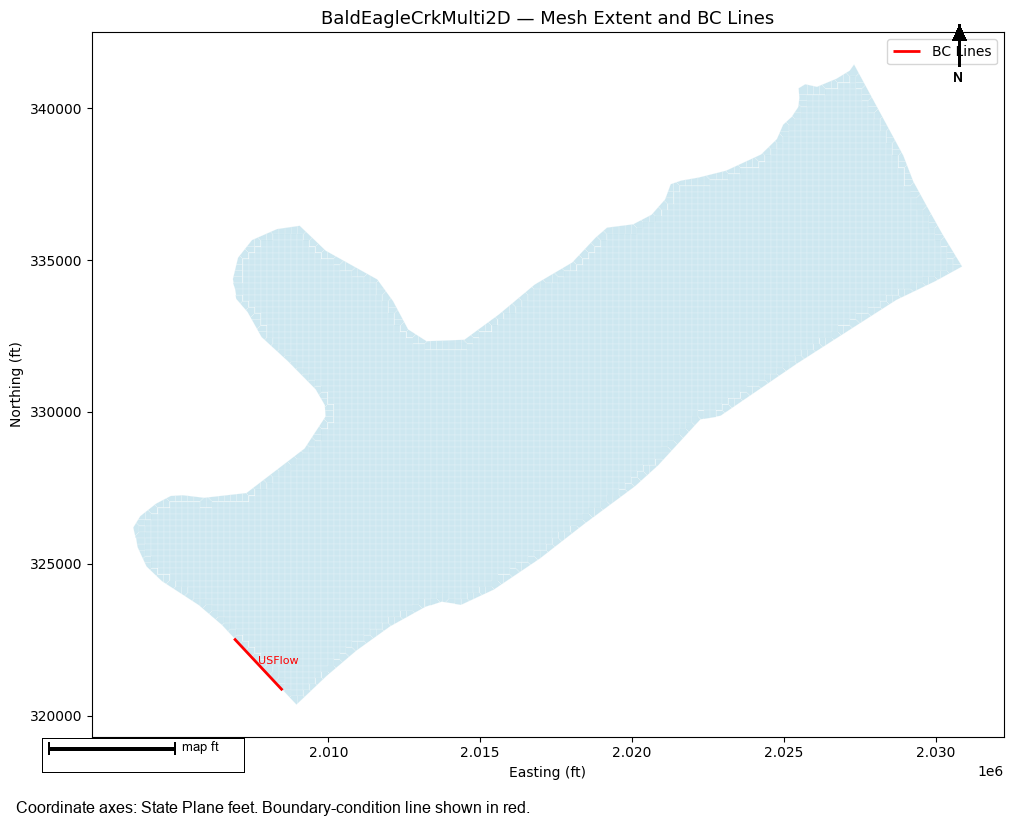

In [6]:
# Visualize mesh extent and BC lines
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# Get mesh cell polygons for context
if geom_hdf.exists():
    try:
        cell_polys = HdfMesh.get_mesh_cell_polygons(geom_hdf)
        if cell_polys is not None and len(cell_polys) > 0:
            cell_polys.plot(ax=ax, color='lightblue', edgecolor='white', linewidth=0.2, alpha=0.6)
            print(f"Plotted {len(cell_polys)} mesh cells")
    except Exception as e:
        print(f"Could not plot cell polygons: {e}")

# Plot BC lines
if bc_lines is not None and len(bc_lines) > 0:
    bc_lines.plot(ax=ax, color='red', linewidth=2, label='BC Lines')
    name_col = 'Name' if 'Name' in bc_lines.columns else bc_lines.columns[0]
    for _, row in bc_lines.iterrows():
        centroid = row.geometry.centroid
        ax.annotate(row[name_col], (centroid.x, centroid.y), fontsize=8, color='red')

ax.set_title(f"{PROJECT_NAME} — Mesh Extent and BC Lines", fontsize=13)
ax.set_xlabel("Easting (ft)")
ax.set_ylabel("Northing (ft)")
handles, labels = ax.get_legend_handles_labels()
if handles:
    ax.legend()
plt.tight_layout()
plt.show()


In [7]:
# Define downstream profile line at the 2D-to-1D connection boundary.
#
# In BaldEagleCrkMulti2D, the "Upstream2D" mesh connects to the 1D river
# reach at XS 50335 (see .g10 file: "Reach Upstream Storage Area=Upstream2D").
# The XS 50335 cut line defines the mesh boundary where flow exits the 2D area.
#
# Coordinates from BaldEagleDamBrk.g10 (XS GIS Cut Line, 5 points):
downstream_profile_line = LineString([
    (2027293.96, 341465.78),   # NW end
    (2028880.13, 338533.77),
    (2029280.67, 337588.47),
    (2030145.86, 335986.28),
    (2030914.91, 334768.61),   # SE end
])

print("Downstream profile line: 2D-to-1D connection at XS 50335")
print(f"  Points : {len(downstream_profile_line.coords)}")
print(f"  Length : {downstream_profile_line.length:.0f} ft")
x_vals = [c[0] for c in downstream_profile_line.coords]
y_vals = [c[1] for c in downstream_profile_line.coords]
print(f"  X range: {min(x_vals):,.0f} – {max(x_vals):,.0f}")
print(f"  Y range: {min(y_vals):,.0f} – {max(y_vals):,.0f}")

# Show BC lines for context
if bc_lines is not None and len(bc_lines) > 0:
    name_col = 'Name' if 'Name' in bc_lines.columns else bc_lines.columns[0]
    print(f"\nBC lines in this model (for reference):")
    for _, row in bc_lines.iterrows():
        centroid = row.geometry.centroid
        print(f"  '{row[name_col]}' centroid: ({centroid.x:,.0f}, {centroid.y:,.0f}) — UPSTREAM inflow BC")
    print("Note: The only BC line (USFlow) is the upstream boundary, not the downstream measurement point.")
    print("The downstream profile line above traces the mesh/river connection, not a BC line.")


Downstream profile line: 2D-to-1D connection at XS 50335
  Points : 5
  Length : 7621 ft
  X range: 2,027,294 – 2,030,915
  Y range: 334,769 – 341,466

BC lines in this model (for reference):
  'USFlow' centroid: (2,007,695, 321,684) — UPSTREAM inflow BC
Note: The only BC line (USFlow) is the upstream boundary, not the downstream measurement point.
The downstream profile line above traces the mesh/river connection, not a BC line.


In [8]:
# Profile line is already defined above from the XS 50335 cut line coordinates.
# For a different model, replace the coordinates in the cell above with your transect.
print(f"Downstream profile line confirmed: {downstream_profile_line.geom_type}, "
      f"{len(list(downstream_profile_line.coords))} vertices")
print(f"  Length : {downstream_profile_line.length:.0f} ft")
print(f"  Y range: {min(c[1] for c in downstream_profile_line.coords):,.0f} – "
      f"{max(c[1] for c in downstream_profile_line.coords):,.0f}")


Downstream profile line confirmed: LineString, 5 vertices
  Length : 7621 ft
  Y range: 334,769 – 341,466


### 1.4 — Write Stepped Hydrograph

Write the stepped inflow hydrograph to the upstream boundary condition.
Each flow is held for `step_duration_hours` so the 2D model reaches steady state.

In [9]:
# Find the unsteady flow file for this plan
plan_row = ras.plan_df[ras.plan_df['plan_number'] == PLAN_NUMBER].iloc[0]
unsteady_num = plan_row.get('unsteady_number', UNSTEADY_NUMBER)
unsteady_file = ras.project_folder / f"{ras.project_name}.u{unsteady_num}"
print(f"Unsteady file: {unsteady_file.name}")

# Write stepped hydrograph with explicit flow list
flows_written = RasModPuls.write_stepped_hydrograph(
    unsteady_file=unsteady_file,
    flows=FLOW_LIST,
    step_duration_hours=STEP_DURATION_HOURS,
    warmup_flow=WARMUP_FLOW,
    warmup_duration_hours=WARMUP_DURATION,
    ras_object=ras,
)

print(f"\nFlows written ({len(flows_written)} steps):")
for i, f in enumerate(flows_written):
    print(f"  Step {i+1}: {f:,.0f} cfs (holds for {STEP_DURATION_HOURS:.0f} hr)")

2026-06-11 16:59:31 - ras_commander.RasModPuls - INFO - Writing stepped hydrograph: 4 steps, flows=[500, 1000, 2000, 5000], step_duration=3.0h


2026-06-11 16:59:31 - ras_commander.RasUnsteady - INFO - Updated Flow Hydrograph inline hydrograph in BaldEagleDamBrk.u09: 14 values, interval=1HOUR, peak=5000.00


2026-06-11 16:59:31 - ras_commander.RasModPuls - INFO - Stepped hydrograph written: 4 steps, total duration = 13.0 hours


Unsteady file: BaldEagleDamBrk.u09

Flows written (4 steps):
  Step 1: 500 cfs (holds for 3 hr)
  Step 2: 1,000 cfs (holds for 3 hr)
  Step 3: 2,000 cfs (holds for 3 hr)
  Step 4: 5,000 cfs (holds for 3 hr)


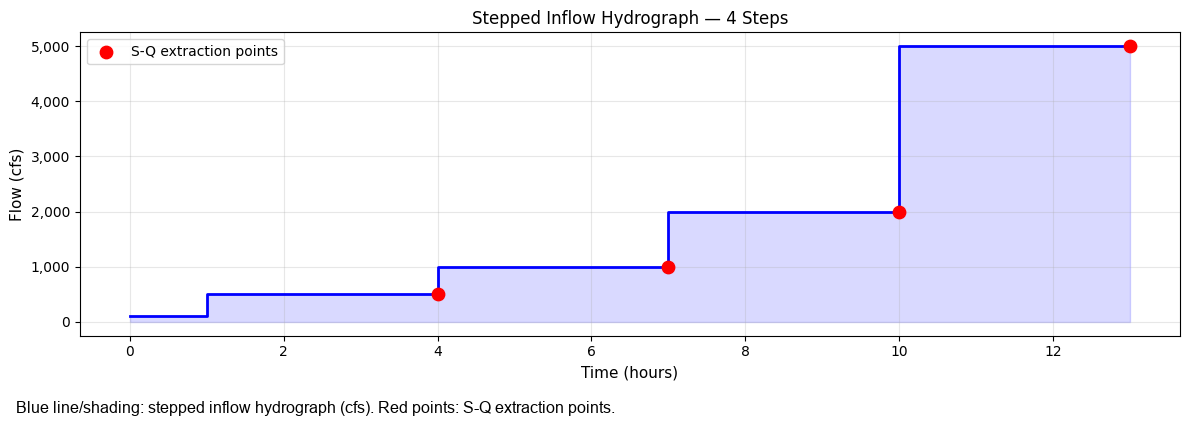

Total simulation duration: 13 hours (0.5 days)


In [10]:
# Visualize the stepped hydrograph that was written
hours = []
values = []
current_hour = 0.0

# Warmup
hours.extend([current_hour, current_hour + WARMUP_DURATION])
values.extend([WARMUP_FLOW, WARMUP_FLOW])
current_hour += WARMUP_DURATION

# Steps
for f in flows_written:
    hours.extend([current_hour, current_hour + STEP_DURATION_HOURS])
    values.extend([f, f])
    current_hour += STEP_DURATION_HOURS

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(hours, values, 'b-', linewidth=2)
ax.fill_between(hours, values, alpha=0.15, color='blue')

# Mark plateau end times
plateau_times = [WARMUP_DURATION + (i+1)*STEP_DURATION_HOURS for i in range(len(flows_written))]
plateau_flows = flows_written
ax.scatter(plateau_times, plateau_flows, color='red', zorder=5, label='S-Q extraction points', s=80)

ax.set_xlabel("Time (hours)", fontsize=11)
ax.set_ylabel("Flow (cfs)", fontsize=11)
ax.set_title(f"Stepped Inflow Hydrograph — {len(flows_written)} Steps", fontsize=12)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{x:,.0f}'))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

total_hours = WARMUP_DURATION + len(flows_written) * STEP_DURATION_HOURS
print(f"Total simulation duration: {total_hours:.0f} hours ({total_hours/24:.1f} days)")

### 1.5 — Execute Plan

Run the 2D HEC-RAS simulation. The model will run the full stepped hydrograph.

> **Note**: Ensure the plan has **Face Flow** output enabled in the Output tab of the
> Unsteady Flow Analysis dialog. Cell Depth output is **not required** — storage is
> computed from Water Surface minus Cells Minimum Elevation, which is always present in HDF.

In [11]:
# Execute plan
result = RasCmdr.compute_plan(
    plan_number=PLAN_NUMBER,
    ras_object=ras,
    num_cores=4,
)

# Verify HDF created
plan_row = ras.plan_df[ras.plan_df['plan_number'] == PLAN_NUMBER].iloc[0]
hdf_path = plan_row['HDF_Results_Path']
if hdf_path and Path(hdf_path).exists():
    print(f"HDF created: {Path(hdf_path).name}")
    print(f"HDF size: {Path(hdf_path).stat().st_size / 1e6:.1f} MB")
else:
    print(f"WARNING: HDF not found. Check plan execution.")

2026-06-11 16:59:31 - ras_commander.RasCmdr - INFO - Using ras_object with project folder: <workspace>\examples\example_projects\BaldEagleCrkMulti2D_560ex1


2026-06-11 16:59:31 - ras_commander.RasUtils - INFO - Successfully updated file: <workspace>\examples\example_projects\BaldEagleCrkMulti2D_560ex1\BaldEagleDamBrk.p17


2026-06-11 16:59:31 - ras_commander.RasCmdr - INFO - Set number of cores to 4 for plan: 17


2026-06-11 16:59:31 - ras_commander.RasCmdr - INFO - Running HEC-RAS from the Command Line:


2026-06-11 16:59:31 - ras_commander.RasCmdr - INFO - Running command: "<hec_ras_install>\7.0\Ras.exe" -c "<workspace>\examples\example_projects\BaldEagleCrkMulti2D_560ex1\BaldEagleDamBrk.prj" "<workspace>\examples\example_projects\BaldEagleCrkMulti2D_560ex1\BaldEagleDamBrk.p17"


2026-06-11 16:59:31 - ras_commander.RasDialogWatchdog - INFO - DialogWatchdog started — polling every 1.5s for RAS dialog windows


2026-06-11 17:00:39 - ras_commander.RasCmdr - INFO - HEC-RAS execution completed for plan: 17


2026-06-11 17:00:39 - ras_commander.RasCmdr - INFO - Total run time for plan 17: 68.50 seconds


2026-06-11 17:00:39 - ras_commander.RasDialogWatchdog - INFO - DialogWatchdog stopped — no dialogs encountered


HDF created: BaldEagleDamBrk.p17.hdf
HDF size: 11.3 MB


### 1.6 — Extract S-Q Table

Read the Face Flow and cell Depth time series from the HDF to extract the
storage-outflow pair at the end of each stepped plateau.

In [12]:
# Extract storage-outflow table from HDF results
sq_df = RasModPuls.extract_storage_outflow(
    plan_hdf_path=PLAN_NUMBER,      # Use plan number — auto-resolves to HDF via ras_object
    downstream_profile_line=downstream_profile_line,
    plan_number=PLAN_NUMBER,
    step_duration_hours=STEP_DURATION_HOURS,
    warmup_duration_hours=WARMUP_DURATION,
    n_steps=len(FLOW_LIST),
    ras_object=ras,
    n_rows=N_ROWS,
)

print(f"S-Q Table ({len(sq_df)} rows):")
print(sq_df.to_string(index=False, float_format='{:.2f}'.format))

2026-06-11 17:00:40 - ras_commander.RasModPuls - INFO - Extracting S-Q table from BaldEagleDamBrk.p17.hdf


2026-06-11 17:01:09 - ras_commander.hdf.HdfMesh - INFO - Found 30 faces along profile line


2026-06-11 17:01:09 - ras_commander.RasModPuls - INFO - Found 30 faces along downstream profile line


2026-06-11 17:01:09 - ras_commander.RasModPuls - INFO - Detected 4 plateau timesteps


2026-06-11 17:01:09 - ras_commander.RasModPuls - INFO - S-Q extraction complete: 5 rows, Q range: 0 - 198 cfs, S range: 0.0 - 3529.7 ac-ft


S-Q Table (5 rows):
 storage_acft  outflow_cfs
         0.00         0.00
      3519.14        31.42
      3522.66       110.30
      3526.19       169.55
      3529.71       197.90


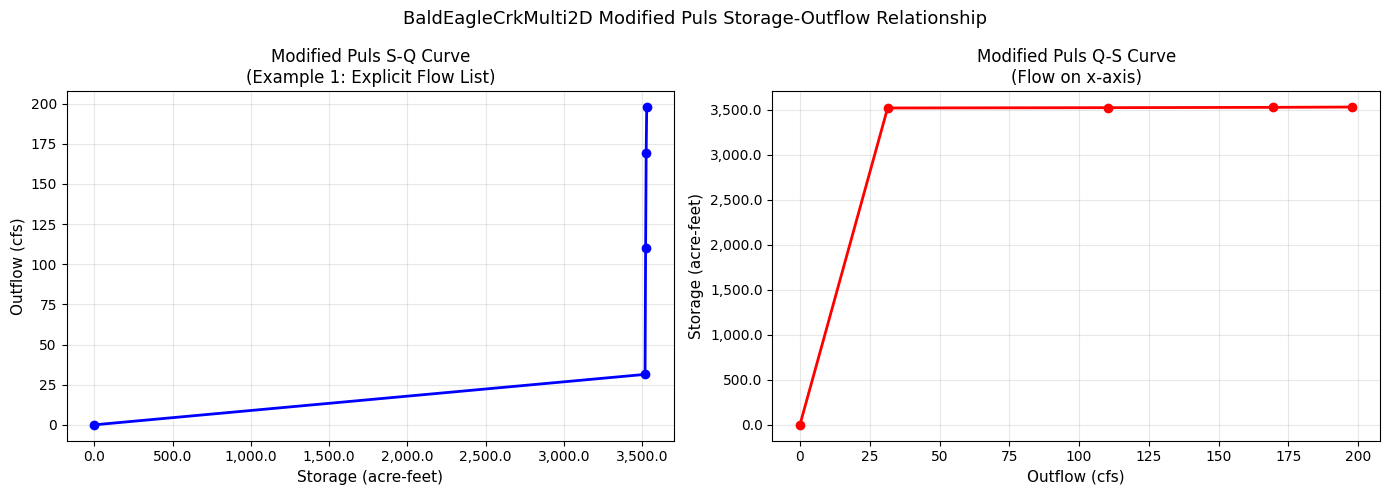

In [13]:
# Plot S-Q curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# S vs Q (standard Modified Puls plot)
ax1.plot(sq_df['storage_acft'], sq_df['outflow_cfs'], 'bo-', markersize=6, linewidth=2)
ax1.set_xlabel("Storage (acre-feet)", fontsize=11)
ax1.set_ylabel("Outflow (cfs)", fontsize=11)
ax1.set_title("Modified Puls S-Q Curve\n(Example 1: Explicit Flow List)", fontsize=12)
ax1.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{x:,.1f}'))
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{x:,.0f}'))
ax1.grid(True, alpha=0.3)

# Q vs S (flow on x-axis for comparison to inflow hydrograph)
ax2.plot(sq_df['outflow_cfs'], sq_df['storage_acft'], 'ro-', markersize=6, linewidth=2)
ax2.set_xlabel("Outflow (cfs)", fontsize=11)
ax2.set_ylabel("Storage (acre-feet)", fontsize=11)
ax2.set_title("Modified Puls Q-S Curve\n(Flow on x-axis)", fontsize=12)
ax2.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{x:,.0f}'))
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{x:,.1f}'))
ax2.grid(True, alpha=0.3)

plt.suptitle(f"{PROJECT_NAME} Modified Puls Storage-Outflow Relationship", fontsize=13)
plt.tight_layout()
plt.show()

### 1.7 — Compute Subreach Count

The number of subreaches controls how much diffusion the Modified Puls routing adds.
Region 2 methodology uses the travel time of the ~10-yr event.

**Formula**: `n = ceil(travel_time_hours / dt_hours * 1.5)`, capped at 30.

In [14]:
# Estimate travel time: difference in time of peak between upstream and downstream face flows
# Here we use a simple estimate — in practice, derive from the 10-yr event hydrograph timing
TRAVEL_TIME_HOURS = 4.0    # Estimated 10-yr event travel time through the reach
HMS_DT_HOURS = 1.0          # HEC-HMS routing time step

n_subreaches = RasModPuls.compute_subreach_count(
    travel_time_hours=TRAVEL_TIME_HOURS,
    dt_hours=HMS_DT_HOURS,
    safety_factor=1.5,
    max_subreaches=30,
)

print(f"Travel time: {TRAVEL_TIME_HOURS} hours")
print(f"HMS time step: {HMS_DT_HOURS} hours")
print(f"Subreaches: {n_subreaches}")
print(f"  (= ceil({TRAVEL_TIME_HOURS} / {HMS_DT_HOURS} × 1.5) = ceil({TRAVEL_TIME_HOURS/HMS_DT_HOURS*1.5:.1f}))")

2026-06-11 17:01:09 - ras_commander.RasModPuls - INFO - Subreach count: n=6 (travel_time=4.0h, dt=1.0h, factor=1.5)


Travel time: 4.0 hours
HMS time step: 1.0 hours
Subreaches: 6
  (= ceil(4.0 / 1.0 × 1.5) = ceil(6.0))


### 1.8 — Write to HEC-HMS (Optional)

Write the S-Q table to a HEC-HMS basin file using `HmsBasin.set_modified_puls_routing()`.
This creates the `.tbl` and `.pdata` paired data files and updates the `.basin` file.

In [15]:
# Optional: write to HEC-HMS
# Uncomment and set basin_path and reach_name to use

WRITE_TO_HMS = False  # <-- Set True to write to HMS
HMS_BASIN_PATH = "path/to/MyProject.basin"  # Update this path
HMS_REACH_NAME = "Reach-1"                  # Update this reach name

if WRITE_TO_HMS:
    try:
        import sys
        sys.path.insert(0, str(Path.cwd().parent.parent / 'hms-commander'))
        from hms_commander import HmsBasin

        table_name = HmsBasin.set_modified_puls_routing(
            basin_path=HMS_BASIN_PATH,
            reach_name=HMS_REACH_NAME,
            sd_df=sq_df,
            number_of_subreaches=n_subreaches,
        )
        print(f"Written to HMS: table='{table_name}', subreaches={n_subreaches}")
    except ImportError:
        print("hms-commander not available — install from C:/GH/hms-commander")
else:
    print("HMS write skipped (set WRITE_TO_HMS = True to enable)")

if 'sq_df' in dir() and sq_df is not None:
    print(f"\nS-Q table ready for HMS (first 5 rows):")
    print(sq_df.head().to_string(index=False))


HMS write skipped (set WRITE_TO_HMS = True to enable)

S-Q table ready for HMS (first 5 rows):
 storage_acft  outflow_cfs
     0.000000     0.000000
  3519.144904    31.415112
  3522.664048   110.304398
  3526.186713   169.545563
  3529.712899   197.904999


In [16]:
# Example 2 configuration — log-spaced flows (shorter steps for demo)
MIN_FLOW = 200.0   # cfs — minimum flow step
MAX_FLOW = 5000.0  # cfs — maximum flow step (same range as Example 1 for comparison)
N_STEPS = 5        # Number of log-spaced steps
STEP_DUR_2 = 3.0   # Hours per step (same as Example 1 for fair comparison)

# Extract fresh copy of project for Example 2
project_folder2 = RasExamples.extract_project(PROJECT_NAME, suffix="560ex2")
from ras_commander import RasPrj
ras2 = RasPrj()
init_ras_project(project_folder2, RAS_VERSION, ras_object=ras2)
print(f"Example 2 project: {project_folder2.name}")

total_h2 = N_STEPS * STEP_DUR_2
print(f"Log-spaced steps: {N_STEPS} steps × {STEP_DUR_2:.0f}h = {total_h2:.0f} hours")


2026-06-11 17:01:10 - ras_commander.RasExamples - INFO - Successfully extracted project 'BaldEagleCrkMulti2D' to <workspace>\examples\example_projects\BaldEagleCrkMulti2D_560ex2


2026-06-11 17:01:10 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 7.0 at <hec_ras_install>\7.0\Ras.exe via filesystem (x86)


2026-06-11 17:01:10 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.7 Beta 5 at <hec_ras_install>\6.7 Beta 5\Ras.exe via filesystem (x86)


2026-06-11 17:01:10 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.6 at <hec_ras_install>\6.6\Ras.exe via filesystem (x86)


2026-06-11 17:01:10 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.5 at <hec_ras_install>\6.5\Ras.exe via filesystem (x86)


...

2026-06-11 17:01:11 - ras_commander.RasPrj - INFO - ras-commander v0.98.0 | An open-source project of CLB Engineering Corporation (https://clbengineering.com/) | Docs: https://rascommander.info | GitHub: https://github.com/gpt-cmdr/ras-commander


2026-06-11 17:01:11 - ras_commander.RasPrj - INFO - Project initialized: BaldEagleDamBrk | Folder: <workspace>\examples\example_projects\BaldEagleCrkMulti2D_560ex2


2026-06-11 17:01:11 - ras_commander.RasPrj - INFO - Using HEC-RAS executable: <hec_ras_install>\7.0\Ras.exe


2026-06-11 17:01:11 - ras_commander.RasPrj - INFO - 
═══════════════════════════════════════════════════════════════════════
ras-commander | HEC-RAS Automation Library
Docs: https://rascommander.info/
Repo: https://github.com/gpt-cmdr/ras-commander
═══════════════════════════════════════════════════════════════════════

PROJECT DATAFRAMES (single source of truth — use these, not file globbing):
  ras_object.plan_df        Plans, HDF paths, geometry/flow associations
  ras_object.geom_df        Geometry files and HDF preprocessor paths
  ras_object.flow_df        Steady flow files
  ras_object.unsteady_df    Unsteady flow files and configurations
  ras_object.boundaries_df  Boundary conditions (type, name, location)
  ras_object.results_df     Lightweight HDF results summaries
  ras_object.rasmap_df      RASMapper layers, terrain, land cover paths

KEY APIS (static classes — call directly, never instantiate):
  Execution:    RasCmdr.compute_plan() / compute_parallel() / compute_test_mod

Example 2 project: BaldEagleCrkMulti2D_560ex2
Log-spaced steps: 5 steps × 3h = 15 hours


In [17]:
# Enable HDF outputs and update simulation date for the Example 2 project
plan_file2 = project_folder2 / f"{ras2.project_name}.p{PLAN_NUMBER}"
content2 = plan_file2.read_text(encoding='utf-8', errors='replace')

if 'HDF Face Flow=' not in content2:
    content2 = content2.replace(
        'HDF Compression=',
        'HDF Face Flow=1 \nHDF Compression='
    )
    print("Enabled: HDF Face Flow in Example 2 plan file")

total_hours2 = N_STEPS * STEP_DUR_2   # no warmup in Example 2
pattern = r'Simulation Date=(\d+[A-Za-z]+\d+),(\d{4}),(\d+[A-Za-z]+\d+),(\d{4})'
match2 = re.search(pattern, content2, re.IGNORECASE)
if match2:
    start_dt2 = datetime.strptime(f"{match2.group(1).upper()} {match2.group(2)}", "%d%b%Y %H%M")
    end_dt2 = start_dt2 + timedelta(hours=total_hours2)
    new_sim_date2 = (
        f"Simulation Date={match2.group(1).upper()},{match2.group(2)},"
        f"{end_dt2.strftime('%d%b%Y').upper()},{end_dt2.strftime('%H%M')}"
    )
    content2 = content2.replace(match2.group(0), new_sim_date2)
    print(f"Simulation date updated: {total_hours2:.0f}h window ending {end_dt2.strftime('%d%b%Y %H%M').upper()}")

plan_file2.write_text(content2, encoding='utf-8')

# Find unsteady file and write log-spaced stepped hydrograph
plan_row2 = ras2.plan_df[ras2.plan_df['plan_number'] == PLAN_NUMBER].iloc[0]
unsteady_num2 = plan_row2.get('unsteady_number', UNSTEADY_NUMBER)
unsteady_file2 = project_folder2 / f"{ras2.project_name}.u{unsteady_num2}"

flows_written2 = RasModPuls.write_stepped_hydrograph(
    unsteady_file=unsteady_file2,
    min_flow=MIN_FLOW,
    max_flow=MAX_FLOW,
    n_steps=N_STEPS,
    step_duration_hours=STEP_DUR_2,
    log_spaced=True,           # Log-spaced for better coverage of flow range
    ras_object=ras2,
)

print(f"\nLog-spaced flows written ({len(flows_written2)} steps):")
for i, f in enumerate(flows_written2):
    print(f"  Step {i+1}: {f:,.0f} cfs")


2026-06-11 17:01:11 - ras_commander.RasModPuls - INFO - Writing stepped hydrograph: 5 steps, flows=[np.float64(200.0), np.float64(447.2), np.float64(1000.0), np.float64(2236.1), np.float64(5000.0)], step_duration=3.0h


2026-06-11 17:01:11 - ras_commander.RasUnsteady - INFO - Updated Flow Hydrograph inline hydrograph in BaldEagleDamBrk.u09: 16 values, interval=1HOUR, peak=5000.00


2026-06-11 17:01:11 - ras_commander.RasModPuls - INFO - Stepped hydrograph written: 5 steps, total duration = 15.0 hours


Enabled: HDF Face Flow in Example 2 plan file
Simulation date updated: 15h window ending 02JAN1999 0300

Log-spaced flows written (5 steps):
  Step 1: 200 cfs
  Step 2: 447 cfs
  Step 3: 1,000 cfs
  Step 4: 2,236 cfs
  Step 5: 5,000 cfs


In [18]:
# Hydrograph write is handled in the cell above (combined with HDF enable + sim date update).
# flows_written2 is already set.
print(f"Example 2 hydrograph summary:")
print(f"  Steps: {len(flows_written2)}")
print(f"  Flow range: {min(flows_written2):,.0f} – {max(flows_written2):,.0f} cfs (log-spaced)")


Example 2 hydrograph summary:
  Steps: 5
  Flow range: 200 – 5,000 cfs (log-spaced)


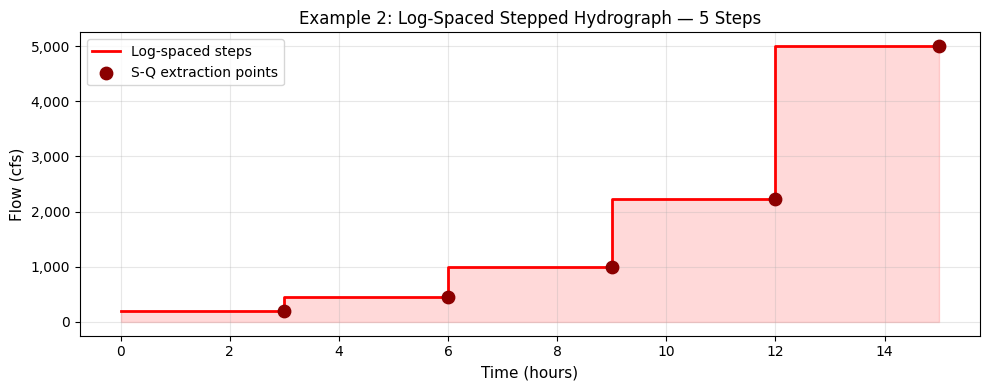

Flow range: 200 – 5,000 cfs (log-spaced)
Total duration: 15 hours


In [19]:
# Visualize the log-spaced stepped hydrograph for Example 2
hours2 = []
values2 = []
current_hour2 = 0.0

for f in flows_written2:
    hours2.extend([current_hour2, current_hour2 + STEP_DUR_2])
    values2.extend([f, f])
    current_hour2 += STEP_DUR_2

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hours2, values2, 'r-', linewidth=2, label='Log-spaced steps')
ax.fill_between(hours2, values2, alpha=0.15, color='red')

plateau_times2 = [(i+1)*STEP_DUR_2 for i in range(len(flows_written2))]
ax.scatter(plateau_times2, flows_written2, color='darkred', zorder=5,
           label='S-Q extraction points', s=80)

ax.set_xlabel("Time (hours)", fontsize=11)
ax.set_ylabel("Flow (cfs)", fontsize=11)
ax.set_title(f"Example 2: Log-Spaced Stepped Hydrograph — {len(flows_written2)} Steps", fontsize=12)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{x:,.0f}'))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Flow range: {min(flows_written2):,.0f} – {max(flows_written2):,.0f} cfs (log-spaced)")
print(f"Total duration: {total_hours2:.0f} hours")

### 2.2 — Optional: Add Reference Lines from BC Lines

Reference lines in the geometry HDF enable native HEC-RAS output at specific locations.
This writes reference lines derived by tracing mesh faces along existing BC lines.

In [20]:
# Execute plan for Example 2
result2 = RasCmdr.compute_plan(
    plan_number=PLAN_NUMBER,
    ras_object=ras2,
    num_cores=4,
)

# Verify HDF created
plan_row2 = ras2.plan_df[ras2.plan_df['plan_number'] == PLAN_NUMBER].iloc[0]
hdf_path2 = plan_row2['HDF_Results_Path']
if hdf_path2 and Path(hdf_path2).exists():
    print(f"HDF created: {Path(hdf_path2).name}")
else:
    print("WARNING: HDF not found for Example 2")

# Extract S-Q table
# Use the same downstream profile line (XS 50335 cut line) — same geometry for both runs
sq_df2 = RasModPuls.extract_storage_outflow(
    plan_hdf_path=PLAN_NUMBER,
    downstream_profile_line=downstream_profile_line,  # Same cut line as Example 1
    plan_number=PLAN_NUMBER,
    step_duration_hours=STEP_DUR_2,
    warmup_duration_hours=0.0,   # No warmup in Example 2
    n_steps=N_STEPS,
    ras_object=ras2,
    n_rows=N_ROWS,
)

print(f"\nS-Q Table Example 2 ({len(sq_df2)} rows):")
print(sq_df2.to_string(index=False, float_format='{:.2f}'.format))

2026-06-11 17:01:11 - ras_commander.RasCmdr - INFO - Using ras_object with project folder: <workspace>\examples\example_projects\BaldEagleCrkMulti2D_560ex2


2026-06-11 17:01:11 - ras_commander.RasUtils - INFO - Successfully updated file: <workspace>\examples\example_projects\BaldEagleCrkMulti2D_560ex2\BaldEagleDamBrk.p17


2026-06-11 17:01:11 - ras_commander.RasCmdr - INFO - Set number of cores to 4 for plan: 17


2026-06-11 17:01:11 - ras_commander.RasCmdr - INFO - Running HEC-RAS from the Command Line:


2026-06-11 17:01:11 - ras_commander.RasCmdr - INFO - Running command: "<hec_ras_install>\7.0\Ras.exe" -c "<workspace>\examples\example_projects\BaldEagleCrkMulti2D_560ex2\BaldEagleDamBrk.prj" "<workspace>\examples\example_projects\BaldEagleCrkMulti2D_560ex2\BaldEagleDamBrk.p17"


...

2026-06-11 17:02:54 - ras_commander.hdf.HdfMesh - INFO - Found 30 faces along profile line


2026-06-11 17:02:54 - ras_commander.RasModPuls - INFO - Found 30 faces along downstream profile line


2026-06-11 17:02:54 - ras_commander.RasModPuls - INFO - Detected 5 plateau timesteps


2026-06-11 17:02:54 - ras_commander.RasModPuls - INFO - S-Q extraction complete: 6 rows, Q range: 0 - 203 cfs, S range: 0.0 - 3546.0 ac-ft



S-Q Table Example 2 (6 rows):
 storage_acft  outflow_cfs
         0.00         0.00
      3531.81        20.08
      3535.34        77.74
      3538.88       112.10
      3542.42       168.39
      3545.96       202.51


In [21]:
# S-Q extraction for Example 2 was completed in the cell above.
# sq_df2 is now ready for comparison plotting.
if 'sq_df2' in dir() and sq_df2 is not None:
    print(f"Example 2 S-Q table: {len(sq_df2)} rows")
    print(f"  Q range: {sq_df2['outflow_cfs'].min():,.0f} – {sq_df2['outflow_cfs'].max():,.0f} cfs")
    print(f"  S range: {sq_df2['storage_acft'].min():,.1f} – {sq_df2['storage_acft'].max():,.1f} ac-ft")


Example 2 S-Q table: 6 rows
  Q range: 0 – 203 cfs
  S range: 0.0 – 3,546.0 ac-ft


In [22]:
# Example 2 execution and S-Q extraction are complete (done in cell above).
# sq_df2 is ready for comparison.
if 'sq_df2' in dir() and sq_df2 is not None:
    print(f"Example 2 S-Q table ready: {len(sq_df2)} rows")
    print(f"  Q range: {sq_df2['outflow_cfs'].min():,.0f} – {sq_df2['outflow_cfs'].max():,.0f} cfs")
    print(f"  S range: {sq_df2['storage_acft'].min():,.1f} – {sq_df2['storage_acft'].max():,.1f} ac-ft")
else:
    print("WARNING: sq_df2 not available — check Example 2 execution cell")

Example 2 S-Q table ready: 6 rows
  Q range: 0 – 203 cfs
  S range: 0.0 – 3,546.0 ac-ft


### 2.4 — Compare S-Q Curves: Explicit vs Log-Spaced

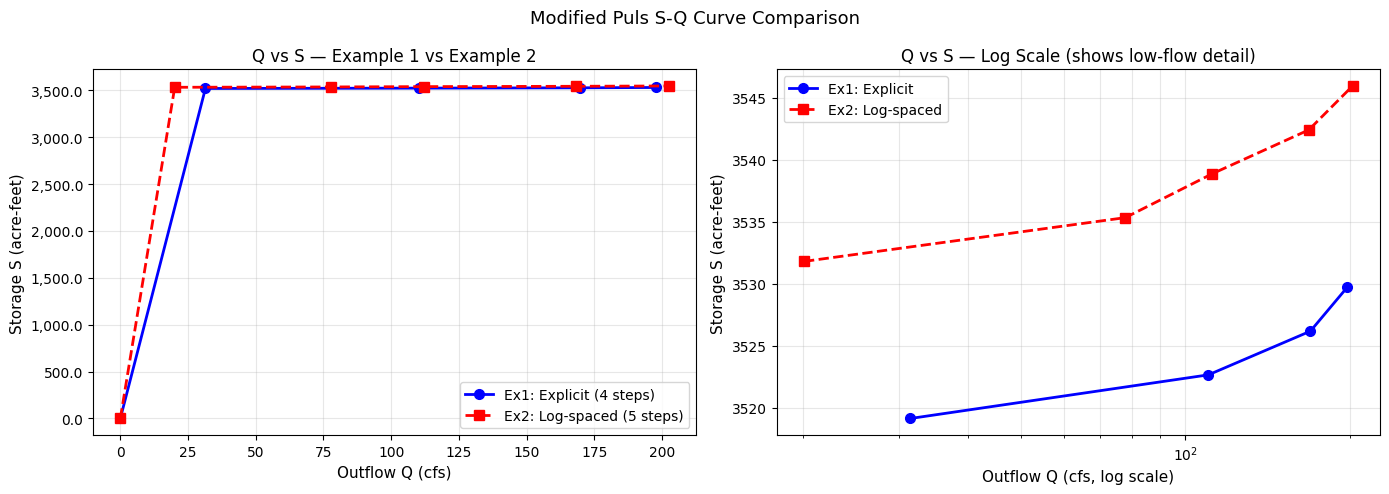

Key comparison:
  Example 1 (explicit): 5 rows, Q range 198 cfs, S range 3,529.7 ac-ft
  Example 2 (log-spaced): 6 rows, Q range 203 cfs, S range 3,546.0 ac-ft

Log-spaced steps provide better coverage at low flows — important for
accurate routing at frequent events (2-yr, 5-yr).


In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Outflow vs Storage
ax1.plot(sq_df['outflow_cfs'], sq_df['storage_acft'], 'bo-',
         markersize=7, linewidth=2, label=f'Ex1: Explicit ({len(FLOW_LIST)} steps)')
ax1.plot(sq_df2['outflow_cfs'], sq_df2['storage_acft'], 'rs--',
         markersize=7, linewidth=2, label=f'Ex2: Log-spaced ({N_STEPS} steps)')
ax1.set_xlabel("Outflow Q (cfs)", fontsize=11)
ax1.set_ylabel("Storage S (acre-feet)", fontsize=11)
ax1.set_title("Q vs S — Example 1 vs Example 2", fontsize=12)
ax1.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{x:,.0f}'))
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{x:,.1f}'))
ax1.legend()
ax1.grid(True, alpha=0.3)

# Log scale to show low-flow detail
ax2.plot(sq_df['outflow_cfs'][sq_df['outflow_cfs'] > 0],
         sq_df['storage_acft'][sq_df['outflow_cfs'] > 0],
         'bo-', markersize=7, linewidth=2, label='Ex1: Explicit')
ax2.plot(sq_df2['outflow_cfs'][sq_df2['outflow_cfs'] > 0],
         sq_df2['storage_acft'][sq_df2['outflow_cfs'] > 0],
         'rs--', markersize=7, linewidth=2, label='Ex2: Log-spaced')
ax2.set_xscale('log')
ax2.set_xlabel("Outflow Q (cfs, log scale)", fontsize=11)
ax2.set_ylabel("Storage S (acre-feet)", fontsize=11)
ax2.set_title("Q vs S — Log Scale (shows low-flow detail)", fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3, which='both')

plt.suptitle("Modified Puls S-Q Curve Comparison", fontsize=13)
plt.tight_layout()
plt.show()

print("Key comparison:")
print(f"  Example 1 (explicit): {len(sq_df)} rows, "
      f"Q range {sq_df['outflow_cfs'].max():,.0f} cfs, "
      f"S range {sq_df['storage_acft'].max():,.1f} ac-ft")
print(f"  Example 2 (log-spaced): {len(sq_df2)} rows, "
      f"Q range {sq_df2['outflow_cfs'].max():,.0f} cfs, "
      f"S range {sq_df2['storage_acft'].max():,.1f} ac-ft")
print("\nLog-spaced steps provide better coverage at low flows — important for")
print("accurate routing at frequent events (2-yr, 5-yr).")

---
## Key Takeaways

### When to Use Each Approach

| Parameter | Explicit List | Log-Spaced Auto |
|-----------|---------------|-----------------|
| **Use when** | Specific return periods needed | General S-Q over full flow range |
| **Flow coverage** | Irregular spacing | Even log-scale coverage |
| **Low-flow detail** | Depends on list | Better (log spacing) |
| **Configuration** | `flows=[...]` | `min_flow`, `max_flow`, `n_steps` |

### Common Pitfalls

1. **Face Flow not enabled**: Ensure `Face Flow` output is checked in the plan's Output settings
2. **Profile line too far from faces**: Increase `distance_threshold` if no faces found
3. **Short steps**: Use at least 12-24 hours per step for steady-state convergence
4. **Flat S-Q curve**: Increase `max_flow` to include flood-relevant flow rates
5. **2D-to-1D topology**: If the 2D mesh discharges into a 1D reach (SA/2D Area connection),
   face-flow Q at the mesh boundary will appear low — the bulk of flow exits through the
   SA-to-river junction, not through 2D mesh faces. Use a fully-enclosed 2D routing reach
   (with downstream BC line, not 1D connection) for accurate S-Q extraction.

### Guidance on Step Duration

- **Recommended**: 24 hours per step for most 2D models
- **Minimum**: 2× the reach travel time at each flow (check velocity outputs)
- **Longer reaches**: May need 48+ hours at high flows

### Subreach Count Formula

```python
n = ceil(travel_time_hours / dt_hours * 1.5)  # capped at 30
```

- `travel_time_hours`: From 2D simulation at ~10-yr event peak flow
- `dt_hours`: HEC-HMS routing time step (typically 1 hour)
- Too few subreaches → numerical instability; too many → artificial damping

## References

- Region 2 (Freese & Nichols) methodology: `raw_operations_region2.txt`, Section 3.8
- HEC-HMS Technical Reference Manual: Modified Puls Routing
- HEC-RAS User Manual: 2D Output Variables
- ras-commander: `RasModPuls` class documentation

In [24]:
# Cleanup extracted projects (optional)
CLEANUP = False  # Set True to delete extracted project folders

if CLEANUP:
    import shutil
    for folder in [project_folder, project_folder2]:
        if folder.exists():
            shutil.rmtree(folder)
            print(f"Removed: {folder}")
else:
    print("Projects preserved (set CLEANUP=True to delete)")
    print(f"  Example 1: {project_folder}")
    print(f"  Example 2: {project_folder2}")

Projects preserved (set CLEANUP=True to delete)
  Example 1: <workspace>\examples\example_projects\BaldEagleCrkMulti2D_560ex1
  Example 2: <workspace>\examples\example_projects\BaldEagleCrkMulti2D_560ex2
